## Trees and forests: Titanic dataset

Data for this script is available in the replication package by the following link:
https://www.openicpsr.org/openicpsr/project/113925/version/V1/view?path=/pcms/projects/1/1/3/9/113925/V1.0.1/ml-data/Titanic&type=folder


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

c:\Users\Popov\anaconda3\envs\IMT_studies\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Upload data

In [2]:
# upload the data
df = pd.read_csv("titanic3.csv")
df.columns = df.columns.str.lower()

# Use only variables from the slide
data = df[["survived", "pclass", "age"]].copy()

# Important for matching the slide: drop missing age
data = data.dropna(subset=["survived", "pclass", "age"])

X = data[["pclass", "age"]]
y = data["survived"]

data.shape

(1046, 3)

### Simple decision tree
#### Training

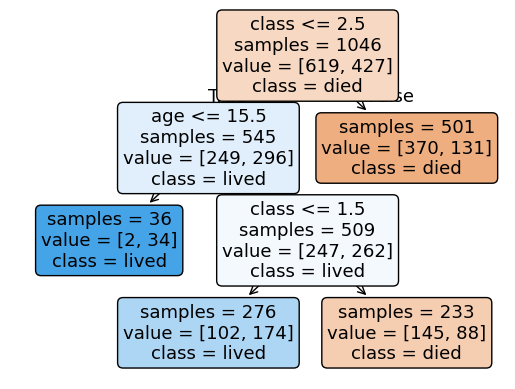

In [3]:
# train the decision tree
tree = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=4,      # slide 8 has 4 terminal nodes - thus the restriction
    random_state=42
)

tree.fit(X, y)

# visualize the tree
plot_tree(
    tree,
    feature_names=["class", "age"],
    class_names=["died", "lived"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False
)

plt.show() # coincides (almost) with the slide!

In [4]:
# learned rules
print(export_text(tree, feature_names=["class", "age"]))

|--- class <= 2.50
|   |--- age <= 15.50
|   |   |--- class: 1
|   |--- age >  15.50
|   |   |--- class <= 1.50
|   |   |   |--- class: 1
|   |   |--- class >  1.50
|   |   |   |--- class: 0
|--- class >  2.50
|   |--- class: 0



In [5]:
# check different metrics 
y_pred = tree.predict(X)
y_proba = tree.predict_proba(X)[:, 1]   # probability of survived = 1

print("Accuracy:", accuracy_score(y, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1-score:", f1_score(y, y_pred))
print("ROC-AUC:", roc_auc_score(y, y_proba))

print("\nConfusion matrix:")
print(confusion_matrix(y, y_pred))

print("\nFull classification report:")
print(classification_report(y, y_pred, target_names=["died", "survived"]))

Accuracy: 0.6912045889101338
Balanced accuracy: 0.6595532569340139
Precision: 0.6666666666666666
Recall: 0.48711943793911006
F1-score: 0.5629228687415426
ROC-AUC: 0.6911162144881258

Confusion matrix:
[[515 104]
 [219 208]]

Full classification report:
              precision    recall  f1-score   support

        died       0.70      0.83      0.76       619
    survived       0.67      0.49      0.56       427

    accuracy                           0.69      1046
   macro avg       0.68      0.66      0.66      1046
weighted avg       0.69      0.69      0.68      1046



#### Partition plot

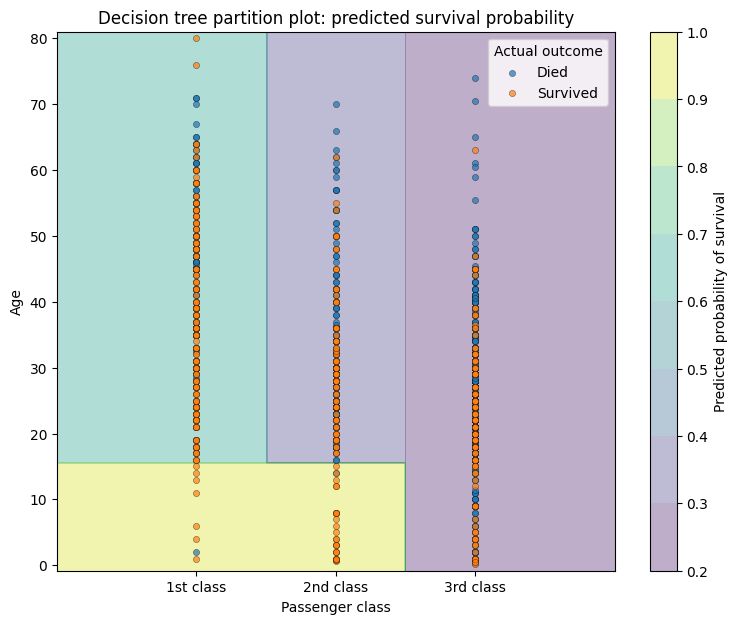

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

disp = DecisionBoundaryDisplay.from_estimator(
    tree,
    X,
    response_method="predict_proba",
    plot_method="contourf",
    grid_resolution=500,
    alpha=0.35,
    ax=ax,
    xlabel="Passenger class",
    ylabel="Age"
)

# Colorbar for predicted probability
fig.colorbar(
    disp.surface_,
    ax=ax,
    label="Predicted probability of survival"
)

# Actual observations, separated for a clean legend
ax.scatter(
    X.loc[y == 0, "pclass"],
    X.loc[y == 0, "age"],
    s=20,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.7,
    label="Died"
)

ax.scatter(
    X.loc[y == 1, "pclass"],
    X.loc[y == 1, "age"],
    s=20,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.7,
    label="Survived"
)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["1st class", "2nd class", "3rd class"])
ax.set_title("Decision tree partition plot: predicted survival probability")

ax.legend(title="Actual outcome")

plt.show()

#### Predicted survaval probabilities

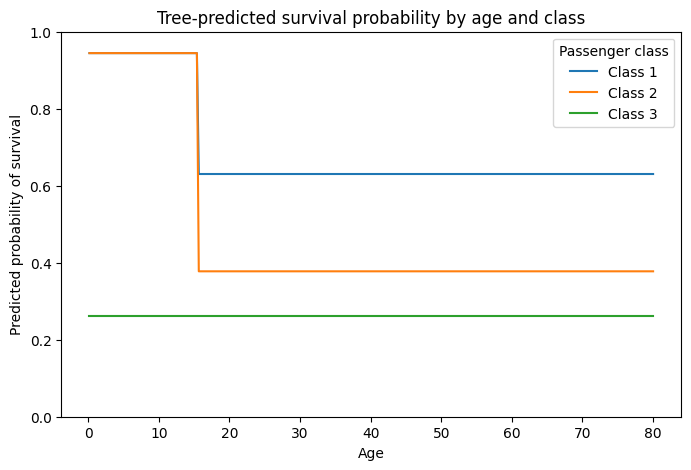

In [7]:
age_grid = np.linspace(data["age"].min(), data["age"].max(), 300)

plt.figure(figsize=(8, 5))

for pclass in [1, 2, 3]:
    X_grid = pd.DataFrame({
        "pclass": pclass,
        "age": age_grid
    })
    
    surv_prob = tree.predict_proba(X_grid)[:, 1]
    
    plt.plot(
        age_grid,
        surv_prob,
        label=f"Class {pclass}"
    )

plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Tree-predicted survival probability by age and class")
plt.legend(title="Passenger class")
plt.ylim(0, 1)

plt.show()

## Simple random forest

In [8]:
# Prepare data
X = data[["pclass", "age"]]
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# train simple decision tree
tree_simple = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=4,
    random_state=42
)

tree_simple.fit(X_train, y_train)

# train random forest
rf = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
# evaluate on test set
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

In [10]:
# compare metrics
results = pd.DataFrame([
    evaluate_model(tree_simple, X_test, y_test, "Decision Tree"),
    evaluate_model(rf, X_test, y_test, "Random Forest")
])

results

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.664122,0.636539,0.611765,0.485981,0.541667,0.645704
1,Random Forest,0.656489,0.632982,0.593407,0.504673,0.545455,0.680314


## RF with tuned hyperparameters (Optuna)

In [11]:
# Define optuna objective function for hyperparameter of RF tuning
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = RandomForestClassifier(**params)
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    return scores.mean()

In [12]:
# run the search
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best ROC-AUC:", study.best_value)
print("Best parameters:")
study.best_params

Best ROC-AUC: 0.7133628813113605
Best parameters:


{'n_estimators': 700,
 'max_depth': 11,
 'min_samples_split': 18,
 'min_samples_leaf': 12,
 'max_features': 'sqrt',
 'criterion': 'gini',
 'bootstrap': True}

In [13]:
# train tuned RF with the best parameters
best_params = study.best_params

rf_tuned = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",11
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# Compare metrics again
results_final = pd.DataFrame([
    evaluate_model(tree_simple, X_test, y_test, "Decision Tree"),
    evaluate_model(rf, X_test, y_test, "Random Forest"),
    evaluate_model(rf_tuned, X_test, y_test, "Tuned Random Forest")
])

results_final

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.664122,0.636539,0.611765,0.485981,0.541667,0.645704
1,Random Forest,0.656489,0.632982,0.593407,0.504673,0.545455,0.680314
2,Tuned Random Forest,0.690840,0.660567,0.662500,0.495327,0.566845,0.667832


We see slight improvement from hyperparameters tuning. Why so small? We still train on only 2 covariates: age and class.